In [18]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import pyproj
import osmnx as ox
import folium
import contextily as ctx
import dataretrieval.nwis as nwis
from shapely.geometry import Point

In [24]:
onp = "Olympic National Park, Washington, USA"

onp_gdf = ox.geocode_to_gdf(onp)
onp_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
# add USGS station locations from streamflow notebook
station_id = stations = [12045500, 12054000, 12056500, 12039500, 12042800, 12041200, 12040500, 12043000, 12048000]
stations_gdf = gpd.GeoDataFrame(station_id, columns=['station_id'])
stations_gdf.index = ['Elwha River', 'Duckabush River', 'NF Skokomish River', 'Quinalt River', 'Bogachiel River', 'Hoh River',
                    'Queets River', 'Calawah River', 'Dungeness River']
geom = []
# the 'dec_lat_va' and 'dec_long_va' were taken from AI since it was helping me navigate the USGS API
for station in station_id:
    coords = nwis.get_record(sites=str(station), service="site")
    lat = coords.iloc[0]['dec_lat_va'] 
    lon = coords.iloc[0]['dec_long_va']
    geom.append(Point(lon, lat))
    
stations_gdf['geometry'] = geom
stations_gdf.set_geometry(stations_gdf['geometry'])
stations_gdf.set_crs('EPSG:4326')

/tmp/ipykernel_475/3193868958.py:14: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  stations_gdf['geometry'] = geom


,station_id,geometry
Elwha River,12045500,POINT (-123.58321 48.05478)
Duckabush River,12054000,POINT (-123.01155 47.68398)
NF Skokomish River,12056500,POINT (-123.32989 47.51426)
Quinalt River,12039500,POINT (-123.88934 47.45759)
Bogachiel River,12042800,POINT (-124.35709 47.89442)
Hoh River,12041200,POINT (-124.25103 47.80675)
Queets River,12040500,POINT (-124.31572 47.53783)
Calawah River,12043000,POINT (-124.39299 47.96008)
Dungeness River,12048000,POINT (-123.13268 48.01426)


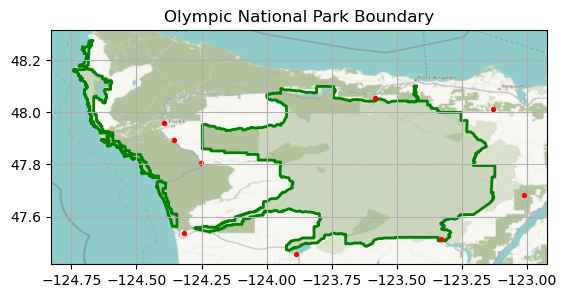

In [33]:
fig, ax = plt.subplots()

onp_gdf.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=2)
stations_gdf.plot(ax=ax, marker='o', markersize = 8, color='red')
ax.set_title("Olympic National Park Boundary")
ctx.add_basemap(ax=ax, attribution = '', crs=onp_gdf.crs) 
ax.grid(True)
ax.set_aspect('equal')
plt.show()